In [1]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

In [ ]:
import numpy 

x = []
x.append(numpy.random.randn(30, 3) )
x.append(numpy.random.randn(30, 3))
x = np.concatenate(x, axis=1)

In [7]:
A = np.array([[1,1],[2,2]])
print(A*A.transpose())

[[1 2]
 [2 4]]


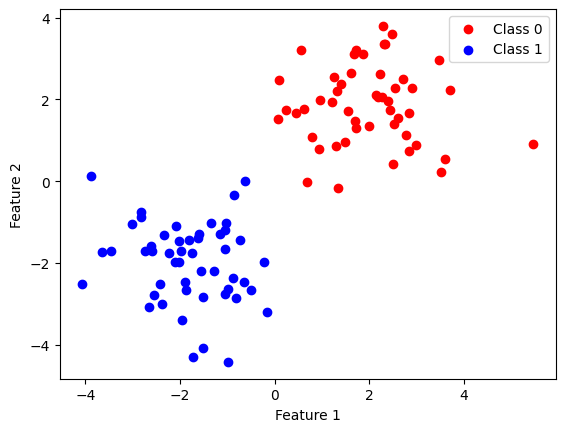

In [8]:
# Generate 50 points for each group
x = []
x.append(np.random.randn(50, 2) + np.array([2, 2]))
x.append(np.random.randn(50, 2) + np.array([-2, -2]))
x = np.concatenate(x, axis=1)

y = np.concatenate([np.zeros(int(x.shape[0]/2)), np.ones(int(x.shape[0]/2))], axis=0)

indx = np.arange(x.shape[0])
np.random.shuffle(indx)

x = x[indx,:]
y = y[indx]

# Plotting the samples
plt.scatter(x[y==0,0], x[y==0,1], color='red', label='Class 0')
plt.scatter(x[y==1,0], x[y==1,1], color='blue', label='Class 1')

# Set plot labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
# plt.grid(True)
plt.show()

In [11]:
w = np.random.rand(x.shape[1])

b = 0.0

# Learning rate
eta = 0.01

def step_function(z):
    return 1 if z > 0 else 0

# Training function
def train_slp(x, y, w, b, eta, epochs):
    n_samples, n_features = x.shape

    for epoch in range(epochs):
        total_error = 0
        for i in range(n_samples):

            z = np.dot(x[i,:], w) + b
            
            y_pred = step_function(z)
            
            error = y[i] - y_pred
            
            w += eta * error * x[i]
            # b += eta * error

            total_error += error ** 2
        
        print(f'Epoch {epoch+1}, Total Error: {total_error}, Weights: {w}, Bias: {b}')
        
        if total_error == 0:
            break

    return w, b

# Train the SLP
epochs = 100
w_final, b_final = train_slp(x, y, w, b, eta, epochs)

print(f'Final Weights: {w_final}, Final Bias: {b_final}')

Epoch 1, Total Error: 13.0, Weights: [-0.02104165 -0.11741845], Bias: 0.0
Epoch 2, Total Error: 0.0, Weights: [-0.02104165 -0.11741845], Bias: 0.0
Final Weights: [-0.02104165 -0.11741845], Final Bias: 0.0


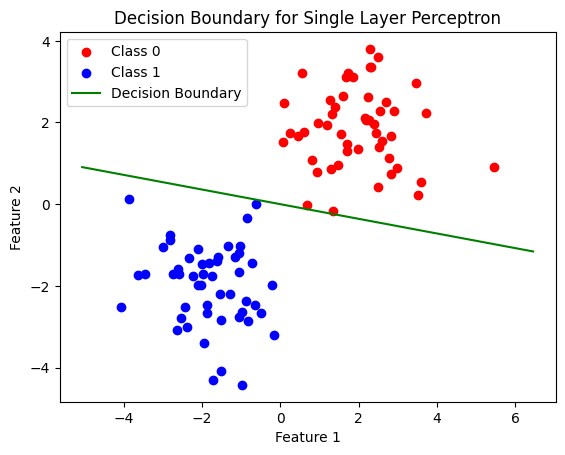

In [12]:
# Plotting the samples
plt.scatter(x[y==0,0], x[y==0,1], color='red', label='Class 0')
plt.scatter(x[y==1,0], x[y==1,1], color='blue', label='Class 1')

x1_vals = np.linspace(min(x[:, 0]) - 1, max(x[:, 0]) + 1, 100)
x2_vals = -(w_final[0] * x1_vals + b_final)/w_final[1]

# Plotting the decision boundary
plt.plot(x1_vals, x2_vals, color='green', label='Decision Boundary')

# Set plot labels and title
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary for Single Layer Perceptron')
plt.legend()
# plt.grid(True)
plt.show()